# Groundwater + rural population + GDP per capita — reconstructed full results

**15-predictor Spatial OOF / SHAP analysis**

このノートブックは保存済みのOOF・SHAP・Permutation importance結果から再構成した、
実行結果付きの閲覧用ノートブックです。モデル学習やSHAP計算は再実行していません。

- 結果ディレクトリ：`/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_gdp_target2020`
- 解析コード本体とは独立した閲覧専用ノートブックです。


In [1]:
from io import BytesIO
import json
from pathlib import Path

import pandas as pd
from PIL import Image as PILImage
from IPython.display import Image as IPImage, Markdown, display

RESULT_DIR = Path(r"/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_gdp_target2020")
assert RESULT_DIR.is_dir(), RESULT_DIR

def show_table(relative_path, caption, max_rows=50):
    path = RESULT_DIR / relative_path
    display(Markdown(f"### {caption}\n\n`{relative_path}`"))
    if not path.is_file():
        display(Markdown("**ファイルが見つかりません。**"))
        return
    size_mb = path.stat().st_size / 1024**2
    if size_mb > 25:
        frame = pd.read_csv(path, nrows=max_rows)
        note = f"先頭{len(frame):,}行のみ表示（ファイルサイズ {size_mb:.1f} MB）"
    else:
        frame = pd.read_csv(path)
        note = f"{len(frame):,}行 × {len(frame.columns):,}列"
        if len(frame) > max_rows:
            frame = frame.head(max_rows)
            note += f"；先頭{max_rows}行を表示"
    display(Markdown(note))
    display(frame)

def show_image(relative_path, caption, max_width=1800, max_height=1300):
    path = RESULT_DIR / relative_path
    display(Markdown(f"### {caption}\n\n`{relative_path}`"))
    if not path.is_file():
        display(Markdown("**画像が見つかりません。**"))
        return
    with PILImage.open(path) as source:
        image = source.convert("RGB")
        image.thumbnail((max_width, max_height), PILImage.Resampling.LANCZOS)
        buffer = BytesIO()
        image.save(buffer, format="PNG", compress_level=6)
    display(IPImage(data=buffer.getvalue(), format="png"))

print("Result directory:", RESULT_DIR)
print("Saved files:", sum(path.is_file() for path in RESULT_DIR.rglob("*")))


Result directory: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_gdp_target2020
Saved files: 91


## 1. 実行マニフェストと使用変数


In [2]:
manifest_path = RESULT_DIR / 'groundwater_rural_population_gdp_15feature_run_manifest.json'
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
display(pd.DataFrame({
    "item": [
        "target year", "analysis rows", "features", "Spatial OOF folds",
        "final model", "GDP feature", "GDP factor group",
    ],
    "value": [
        manifest["target_year"], f'{manifest["n_analysis_rows"]:,}',
        manifest["n_features"], manifest["spatial_oof_folds"],
        manifest["final_model"], manifest["gdp_feature"],
        manifest["gdp_factor_group"],
    ],
}))
display(Markdown("### 全説明変数"))
display(pd.DataFrame({
    "number": range(1, len(manifest["features"]) + 1),
    "feature": manifest["features"],
}))
display(Markdown("### 欠損補完とGDPデータ情報"))
manifest_details = {key: value for key, value in manifest.items()
                    if key not in {"features", "global_metrics"}}
display(pd.DataFrame(manifest_details.items(), columns=["key", "value"]))


,item,value
0,target year,2020
1,analysis rows,"240,000"
2,features,15
3,Spatial OOF folds,5
4,final model,soil_group_wetland_excluded_groundwater_rural_...
5,GDP feature,log_gdp_pc_2020_ppp2017usd
6,GDP factor group,Economic prosperity


### 全説明変数

,number,feature
0,1,elevation_m
1,2,slope
2,3,exclusion_class
3,4,log_city_time_20k_min
4,5,log_port_time_any_min
5,6,rainfed_calorie_top5_raw
6,7,irrigation_calorie_gain_top5_raw
7,8,wx_50km_rainfed_calorie_top5_raw
8,9,log_distance_river_gt10_2020
9,10,log_glofas_p10_2020


### 欠損補完とGDPデータ情報

,key,value
0,notebook,/work/tsuda/GAEZ/cropland_soil_group_wetland_e...
1,output_directory,/work/tsuda/GAEZ/CroplandRegression/soil_group...
2,target_year,2020
3,n_analysis_rows,240000
4,n_features,15
5,final_model,soil_group_wetland_excluded_groundwater_rural_...
6,spatial_oof_folds,5
7,gdp_feature,log_gdp_pc_2020_ppp2017usd
8,gdp_definition,"2020 GDP per capita, PPP 2017 international US..."
9,gdp_source_file,/work/tsuda/GAEZ/CroplandRegression/prior_stud...


## 2. 精度・SHAP・Permutation importanceの保存表


In [3]:
table_specs = [('soil_comparison_global_metrics.csv', '土壌群なし／ありモデルの全球Spatial OOF指標'), ('soil_comparison_fold_metrics.csv', 'fold別Spatial OOF指標'), ('soil_model_metric_deltas.csv', '土壌群追加による指標差'), ('soil_comparison_residual_morans_i.csv', "OOF残差のMoran's I"), ('soil_model_oof_shap_summary.csv', '個別変数のOOF SHAP重要度'), ('soil_model_oof_shap_fold_summary.csv', '個別変数のfold別OOF SHAP'), ('soil_model_oof_shap_factor_groups_corrected.csv', '生産要素群別OOF SHAP'), ('soil_group_class_oof_shap_summary.csv', 'WRB土壌群別のsigned OOF SHAP'), ('integrated_final_cropland_group_shap_global.csv', '最終耕作地割合の統合グループShapley'), ('integrated_final_cropland_group_shap_by_fold.csv', '統合グループShapleyのfold別集計'), ('integrated_final_group_summary_bg32_perm32.csv', '全セル統合グループShapley集計'), ('integrated_final_feature_summary_bg32_perm32.csv', '全セル統合個別変数Shapley集計'), ('integrated_shapley_archive_bg32_perm32/integrated_group_shapley_global_summary.csv', '統合グループShapleyアーカイブ集計'), ('integrated_shapley_archive_bg32_perm32/integrated_feature_shapley_global_summary.csv', '統合個別変数Shapleyアーカイブ集計'), ('gdp_15feature_vs_14feature_metrics.csv', 'GDP追加前後のSpatial OOF比較'), ('permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_gdp_spatial_oof_permutation_importance.csv', '個別変数Permutation importance'), ('group_permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_gdp_spatial_oof_group_permutation_importance.csv', '要素群Permutation importance')]
for relative_path, caption in table_specs:
    show_table(relative_path, caption)


### 土壌群なし／ありモデルの全球Spatial OOF指標

`soil_comparison_global_metrics.csv`

4行 × 10列

,model,weighting,n_features,n,observed_mean,predicted_mean,r2,rmse,mae,bias_observed_minus_predicted
0,no_soil_wetland_excluded_groundwater_rural_pop...,unweighted_sample,14,240000,0.139354,0.128715,0.663264,0.128439,0.071648,0.010639
1,no_soil_wetland_excluded_groundwater_rural_pop...,area_weighted_reweighted,14,240000,0.115644,0.112588,0.659867,0.121422,0.065075,0.003056
2,soil_group_wetland_excluded_groundwater_rural_...,unweighted_sample,15,240000,0.139354,0.129449,0.692472,0.122742,0.067875,0.009904
3,soil_group_wetland_excluded_groundwater_rural_...,area_weighted_reweighted,15,240000,0.115644,0.112385,0.686307,0.116607,0.061967,0.003259


### fold別Spatial OOF指標

`soil_comparison_fold_metrics.csv`

10行 × 10列

...

15行 × 11列

,rank,model,feature,baseline_mse,permuted_mse,delta_mse,percent_increase_mse,mean_percent_increase_mse,std_percent_increase_mse,n_folds,n_repeats
0,1,soil_group_wetland_excluded_groundwater_rural_...,log_rural_population_density_2020,0.013597,0.029251,0.015654,115.124951,117.453974,36.950784,5,10
1,2,soil_group_wetland_excluded_groundwater_rural_...,log_city_time_20k_min,0.013597,0.021091,0.007494,55.114942,55.763824,11.861158,5,10
2,3,soil_group_wetland_excluded_groundwater_rural_...,soil_group_class,0.013597,0.017542,0.003945,29.009738,29.157929,5.744707,5,10
3,4,soil_group_wetland_excluded_groundwater_rural_...,wx_50km_rainfed_calorie_top5_raw,0.013597,0.017306,0.003708,27.272084,27.280813,5.484439,5,10
4,5,soil_group_wetland_excluded_groundwater_rural_...,log_gdp_pc_2020_ppp2017usd,0.013597,0.016346,0.002748,20.213528,20.721282,7.288542,5,10
5,6,soil_group_wetland_excluded_groundwater_rural_...,exclusion_class,0.013597,0.015467,0.001869,13.747672,13.765032,1.031608,5,10
6,7,soil_group_wetland_excluded_groundwater_rural_...,irrigation_calorie_gain_top5_raw,0.013597,0.015255,0.001658,12.191578,12.374836,5.445179,5,10
7,8,soil_group_wetland_excluded_groundwater_rural_...,slope,0.013597,0.015007,0.001410,10.366232,10.515740,3.369121,5,10
8,9,soil_group_wetland_excluded_groundwater_rural_...,log_fan_water_table_depth_m,0.013597,0.014716,0.001119,8.230063,8.363872,2.951660,5,10
9,10,soil_group_wetland_excluded_groundwater_rural_...,rainfed_calorie_top5_raw,0.013597,0.014594,0.000997,7.332826,7.599725,3.334512,5,10


### 要素群Permutation importance

`group_permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_gdp_spatial_oof_group_permutation_importance.csv`

5行 × 12列

,rank,model,group,baseline_mse,permuted_mse,delta_mse,percent_increase_mse,mean_percent_increase_mse,std_percent_increase_mse,n_folds,n_repeats,features
0,1,soil_group_wetland_excluded_groundwater_rural_...,Rural population,0.013597,0.029235,0.015637,115.002572,117.353646,37.443744,5,10,log_rural_population_density_2020
1,2,soil_group_wetland_excluded_groundwater_rural_...,Climate and water capital,0.013597,0.026005,0.012408,91.250883,92.613847,20.060986,5,10,"rainfed_calorie_top5_raw, irrigation_calorie_g..."
2,3,soil_group_wetland_excluded_groundwater_rural_...,Land and soil capital,0.013597,0.023388,0.009791,72.003530,72.563918,14.039800,5,10,"elevation_m, slope, exclusion_class, soil_grou..."
3,4,soil_group_wetland_excluded_groundwater_rural_...,Market access and infrastructure,0.013597,0.022155,0.008558,62.935331,63.711080,12.532331,5,10,"log_city_time_20k_min, log_port_time_any_min"
4,5,soil_group_wetland_excluded_groundwater_rural_...,Economic prosperity,0.013597,0.016328,0.002731,20.085138,20.592150,7.215736,5,10,log_gdp_pc_2020_ppp2017usd


## 3. 大規模セル別結果の内容確認


In [4]:
large_data_specs = [('soil_comparison_oof_predictions.csv.gz', 'Spatial OOF予測'), ('soil_model_oof_local_feature_shap.csv.gz', '段階別ローカルOOF SHAP'), ('soil_model_oof_local_group_shap.csv.gz', '要素群別ローカルOOF SHAP'), ('soil_group_oof_local_shap.csv.gz', '土壌群モデルのローカルSHAP'), ('integrated_final_cropland_group_shap_local.csv.gz', '統合グループShapley（セル別）'), ('integrated_final_all_cells_bg32_perm32.csv.gz', '全セル統合Shapley')]
for relative_path, caption in large_data_specs:
    show_table(relative_path, caption, max_rows=8)


### Spatial OOF予測

`soil_comparison_oof_predictions.csv.gz`

240,000行 × 11列；先頭8行を表示

,row,col,lat,lon,spatial_block,presence,cropland_fraction,exclusion_class,soil_group_class,pred_no_soil_wetland_excluded_groundwater_rural_population_gdp,pred_soil_group_wetland_excluded_groundwater_rural_population_gdp
0,235,3297,70.374940,94.791560,603,0,0.000000,1,9,0.000002,8.009095e-08
1,450,889,52.458275,-105.875030,511,1,0.619954,1,6,0.245183,4.532004e-01
2,364,2235,59.624940,6.291592,522,1,0.029087,1,26,0.010508,3.546134e-02
3,1426,3950,-28.875025,149.208200,248,1,0.228243,1,33,0.267868,2.199805e-01
4,834,2094,20.458290,-5.458403,413,0,0.000000,1,4,0.000003,3.041215e-06
5,415,2890,55.374943,60.874905,528,1,0.536518,1,6,0.451766,5.658607e-01
6,213,880,72.208270,-106.625030,583,0,0.000000,1,9,0.000003,2.186812e-06
7,945,2400,11.208293,20.041586,380,1,0.260736,2,28,0.046941,8.356050e-02


### 段階別ローカルOOF SHAP

`soil_model_oof_local_feature_shap.csv.gz`

100,000行 × 37列；先頭8行を表示

...

25,000行 × 16列；先頭8行を表示

,fold,row,col,lat,lon,spatial_block,presence,cropland_fraction,weight,baseline_final_fraction,predicted_final_fraction,shap__land_soil,shap__climate_water,shap__market_infrastructure,shap__rural_population,shap__economic_prosperity
0,1,981,2470,8.208294,25.874918,344,1,0.024286,5228.100829,0.137462,0.007696,0.002855,0.002294,-0.029784,-0.029736,-0.075395
1,1,541,2449,44.874947,24.124918,488,1,0.301929,3743.189775,0.161490,0.222540,-0.006592,0.010493,0.017002,0.028178,0.011969
2,1,711,908,30.708284,-104.291695,439,1,0.036737,4541.481561,0.159986,0.006967,-0.053942,-0.061988,-0.012166,-0.026219,0.001297
3,1,335,451,62.041607,-142.375020,543,0,0.000000,4288.392492,0.119370,0.000870,-0.023004,-0.043318,-0.022547,-0.029014,-0.000616
4,1,427,872,54.374943,-107.291695,511,0,0.000246,5328.298972,0.145263,0.086709,0.023452,0.004369,-0.013956,-0.081856,0.009438
5,1,1262,1615,-15.208364,-45.375053,265,1,0.077541,5097.192297,0.118062,0.150452,0.033690,0.056897,-0.023550,-0.036168,0.001520
6,1,584,2447,41.291615,23.958252,488,1,0.252826,3968.847788,0.113503,0.151368,-0.024622,0.030713,0.025252,-0.005165,0.011687
7,1,1039,2504,3.374963,28.708250,344,1,0.200088,5273.135838,0.074223,0.056944,-0.004302,0.045160,0.009269,0.014679,-0.082084


### 全セル統合Shapley

`integrated_final_all_cells_bg32_perm32.csv.gz`

先頭8行のみ表示（ファイルサイズ 52.2 MB）

,fold,sample_index,row,col,lat,lon,spatial_block,presence,cropland_fraction,weight,...,shap_feature__rainfed_calorie_top5_raw,shap_feature__irrigation_calorie_gain_top5_raw,shap_feature__wx_50km_rainfed_calorie_top5_raw,shap_feature__log_distance_river_gt10_2020,shap_feature__log_glofas_p10_2020,shap_feature__soil_group_class,shap_feature__log_fan_water_table_depth_m,shap_feature__log_watergap_total_recharge_mm_yr,shap_feature__log_rural_population_density_2020,shap_feature__log_gdp_pc_2020_ppp2017usd
0,3,0,235,3297,70.374940,94.791560,603,0,0.000000,320.037166,...,-0.007320,-0.008827,-0.011918,-0.003313,0.000422,-0.010146,0.004308,-0.000118,-0.014214,0.000424
1,1,1,450,889,52.458275,-105.875030,511,1,0.619954,335.292325,...,0.036925,0.017936,0.054473,0.014022,0.001026,0.164609,0.004308,0.010517,-0.029299,0.002993
2,3,2,364,2235,59.624940,6.291592,522,1,0.029087,278.233443,...,-0.020468,-0.005130,-0.037989,-0.002698,0.001122,-0.005187,-0.009578,-0.001760,0.014996,-0.011937
3,2,3,1426,3950,-28.875025,149.208200,248,1,0.228243,481.839804,...,0.014380,0.066461,0.022192,-0.015484,-0.000700,0.005526,0.035727,0.007666,-0.036960,0.008259
4,3,4,834,2094,20.458290,-5.458403,413,0,0.000000,892.761984,...,-0.002890,-0.010165,-0.007365,-0.001372,0.001576,0.000843,0.000523,-0.000005,-0.037057,-0.003954
5,3,5,415,2890,55.374943,60.874905,528,1,0.536518,312.650212,...,0.026203,0.003109,0.092094,0.022303,0.004094,0.126481,0.034518,0.003562,0.022132,0.011562
6,2,6,213,880,72.208270,-106.625030,583,0,0.000000,291.172850,...,-0.011066,-0.008780,-0.017904,-0.007233,0.000995,-0.010307,0.007238,-0.000515,-0.020258,-0.002156
7,1,7,945,2400,11.208293,20.041586,380,1,0.260736,539.736069,...,0.003275,0.009022,0.017016,0.017072,0.005083,-0.002243,0.012399,-0.004432,-0.027281,-0.023471


## モデル精度とGDP追加効果


### モデルが使用した全説明変数の全球分布

`model_input_variable_maps.png`

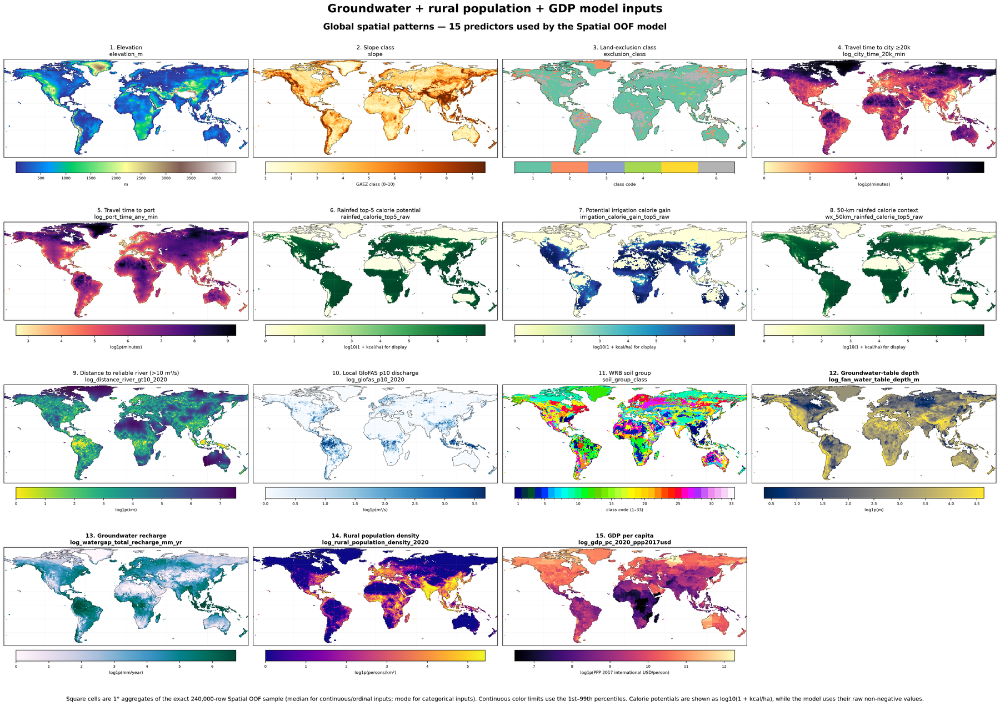

### 土壌群なし／ありモデルのSpatial OOF精度

`soil_ablation_metrics.png`

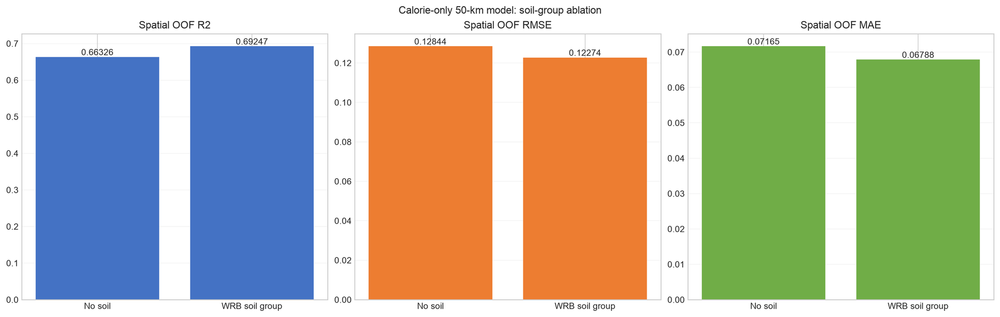

### Spatial OOF予測と残差の空間分布

`spatial_oof_predictions_residuals.png`

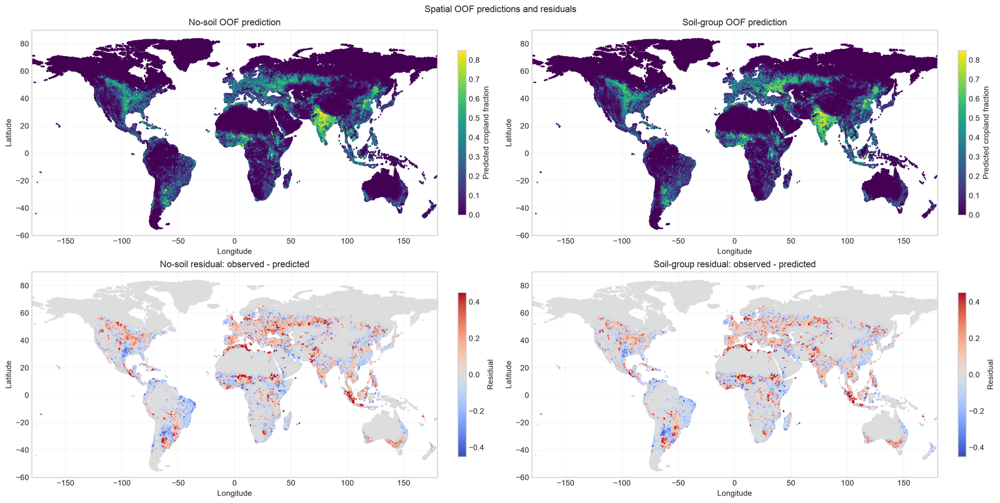

### 最終モデルのSpatial OOF診断

`final_spatial_oof_model_diagnostics.png`

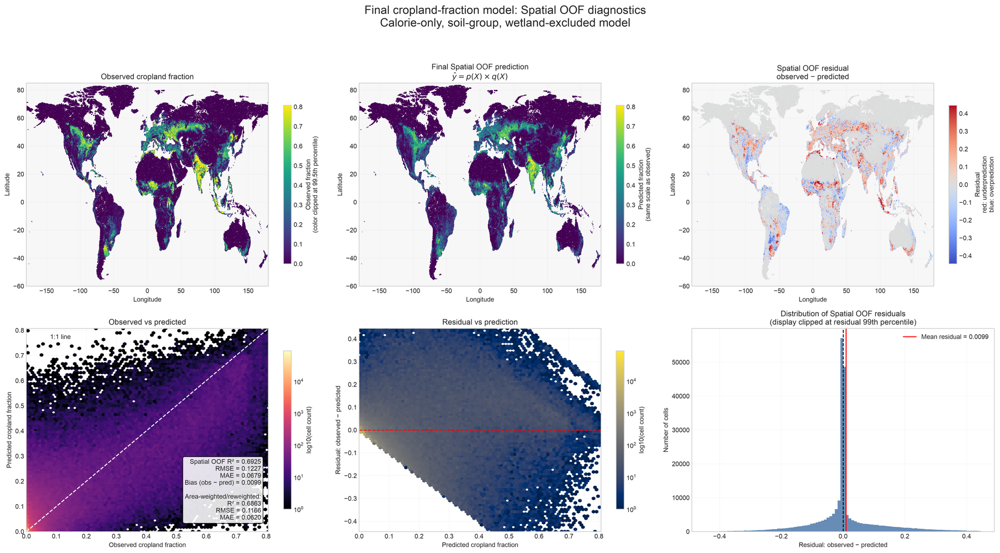

### GDP追加前後のSpatial OOF比較

`gdp_15feature_vs_14feature_summary.png`

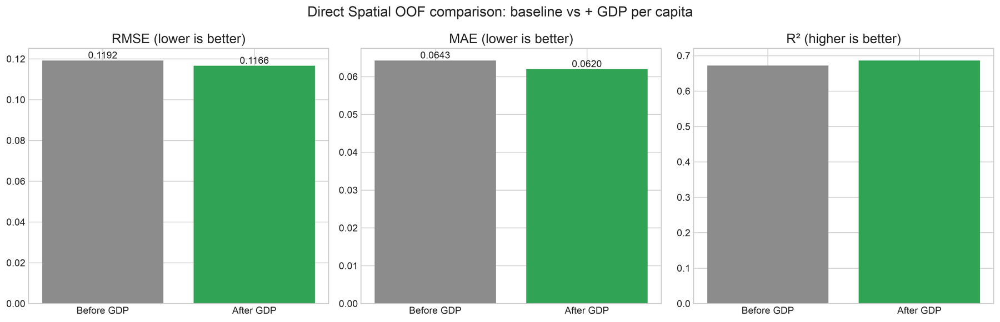

In [5]:
figure_specs = [('model_input_variable_maps.png', 'モデルが使用した全説明変数の全球分布'), ('soil_ablation_metrics.png', '土壌群なし／ありモデルのSpatial OOF精度'), ('spatial_oof_predictions_residuals.png', 'Spatial OOF予測と残差の空間分布'), ('final_spatial_oof_model_diagnostics.png', '最終モデルのSpatial OOF診断'), ('gdp_15feature_vs_14feature_summary.png', 'GDP追加前後のSpatial OOF比較')]
for relative_path, caption in figure_specs:
    show_image(relative_path, caption)


## OOF SHAPと統合Shapley


### 個別変数OOF SHAP重要度

`individual_feature_oof_shap_factor_colored.png`

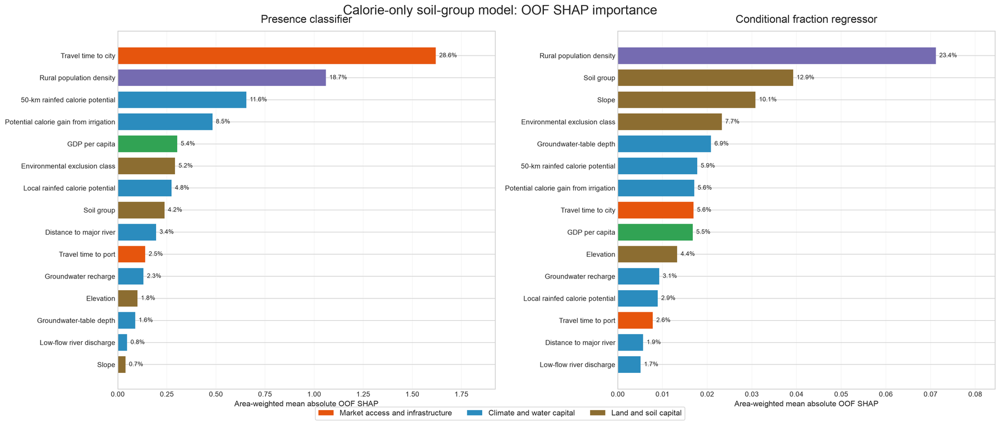

### 生産要素群別OOF SHAP

`factor_group_oof_shap_corrected.png`

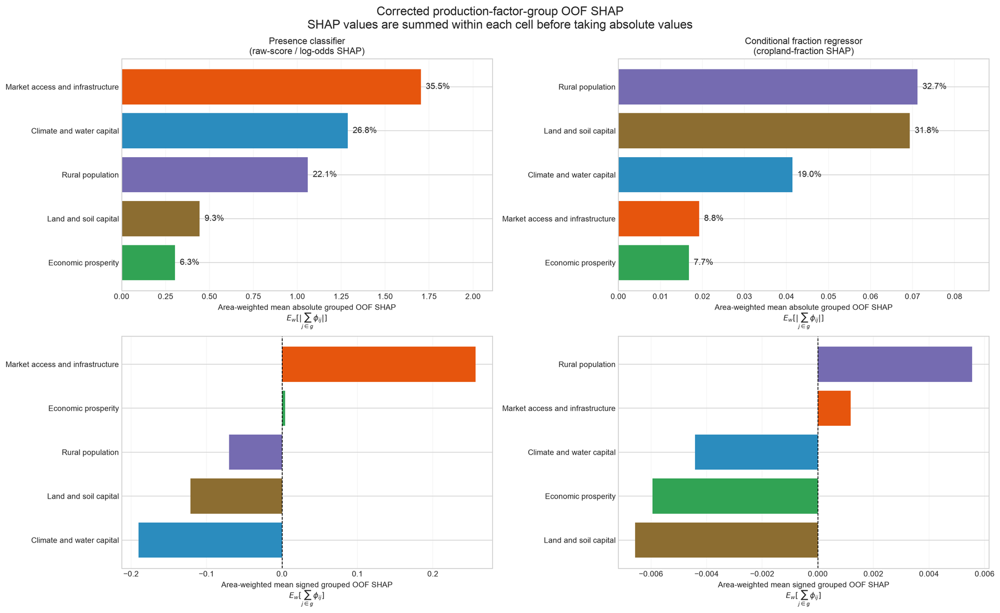

### 旧集計と修正集計の比較

`factor_group_oof_shap_old_vs_corrected.png`

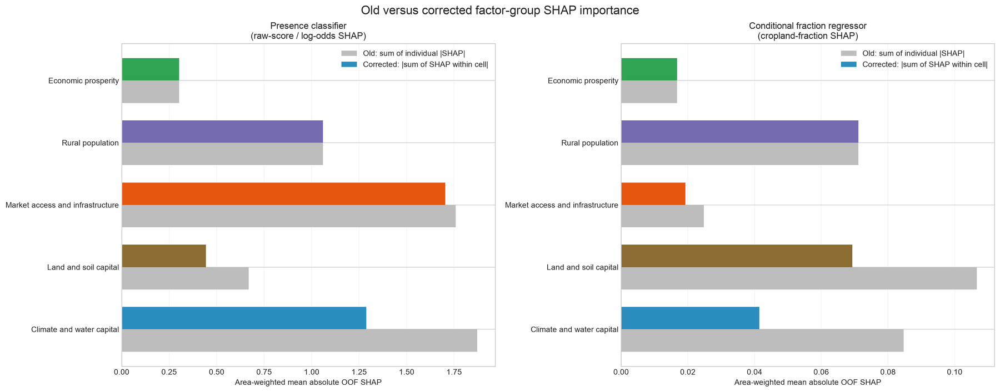

### 土壌群別signed OOF SHAP

`soil_group_signed_oof_shap.png`

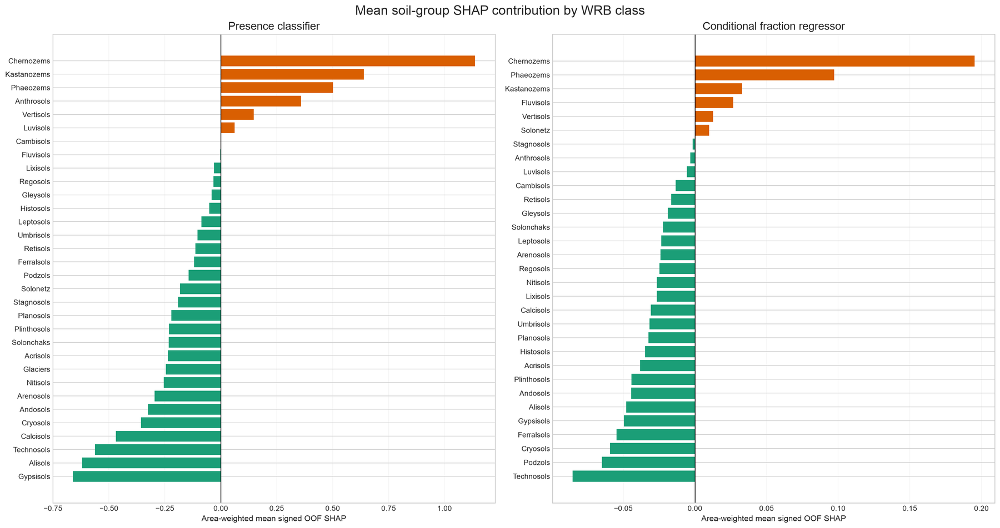

### 最終耕作地割合の統合Shapley

`integrated_final_shapley_summary_bg32_perm32_fixed.png`

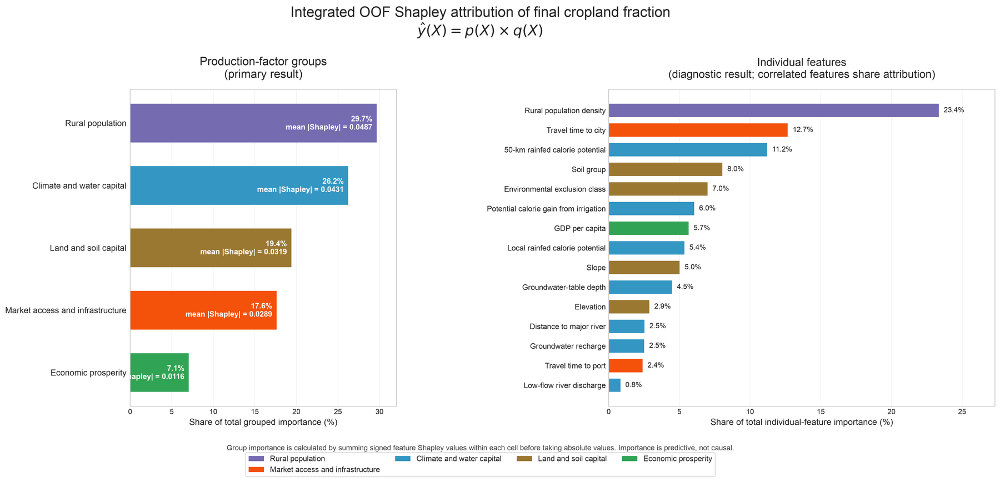

### 各グリッドの支配的生産要素

`final_cropland_dominant_factor_map.png`

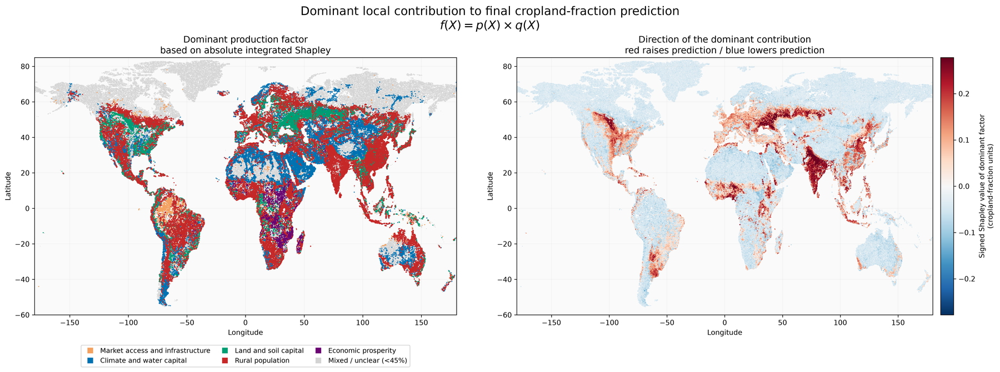

In [6]:
figure_specs = [('individual_feature_oof_shap_factor_colored.png', '個別変数OOF SHAP重要度'), ('factor_group_oof_shap_corrected.png', '生産要素群別OOF SHAP'), ('factor_group_oof_shap_old_vs_corrected.png', '旧集計と修正集計の比較'), ('soil_group_signed_oof_shap.png', '土壌群別signed OOF SHAP'), ('integrated_final_shapley_summary_bg32_perm32_fixed.png', '最終耕作地割合の統合Shapley'), ('final_cropland_dominant_factor_map.png', '各グリッドの支配的生産要素')]
for relative_path, caption in figure_specs:
    show_image(relative_path, caption)


## 段階別signed SHAPとBeeswarm


### Stage 1：耕作地存在分類の要素群別signed SHAP

`signed_factor_maps_stage1_presence.png`

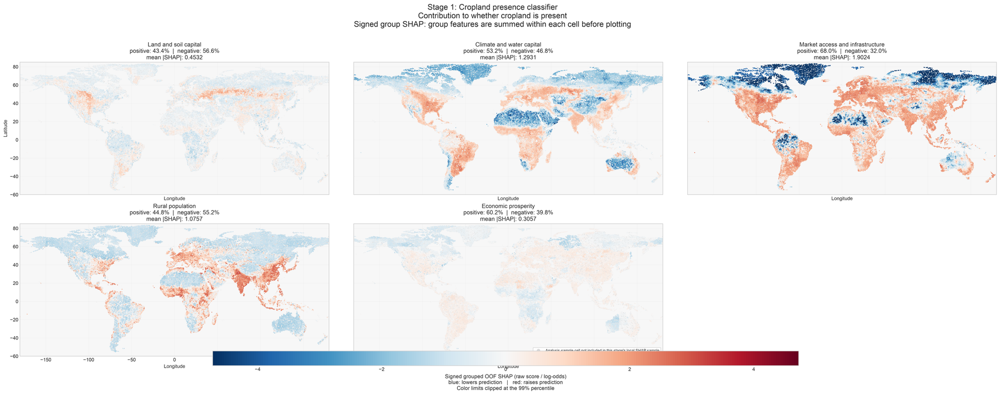

### Stage 2：条件付き耕作地割合の要素群別signed SHAP

`signed_factor_maps_stage2_conditional.png`

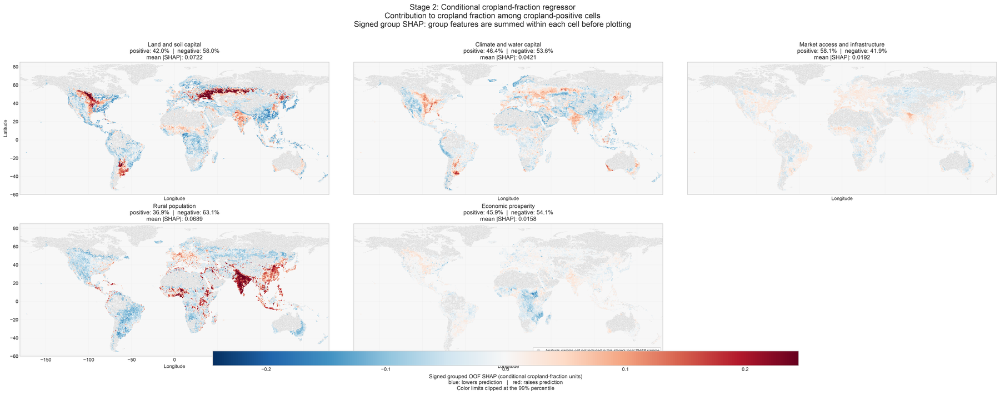

### Stage 1 OOF SHAP beeswarm

`saved_oof_shap_beeswarm/stage1_presence_oof_shap_beeswarm.png`

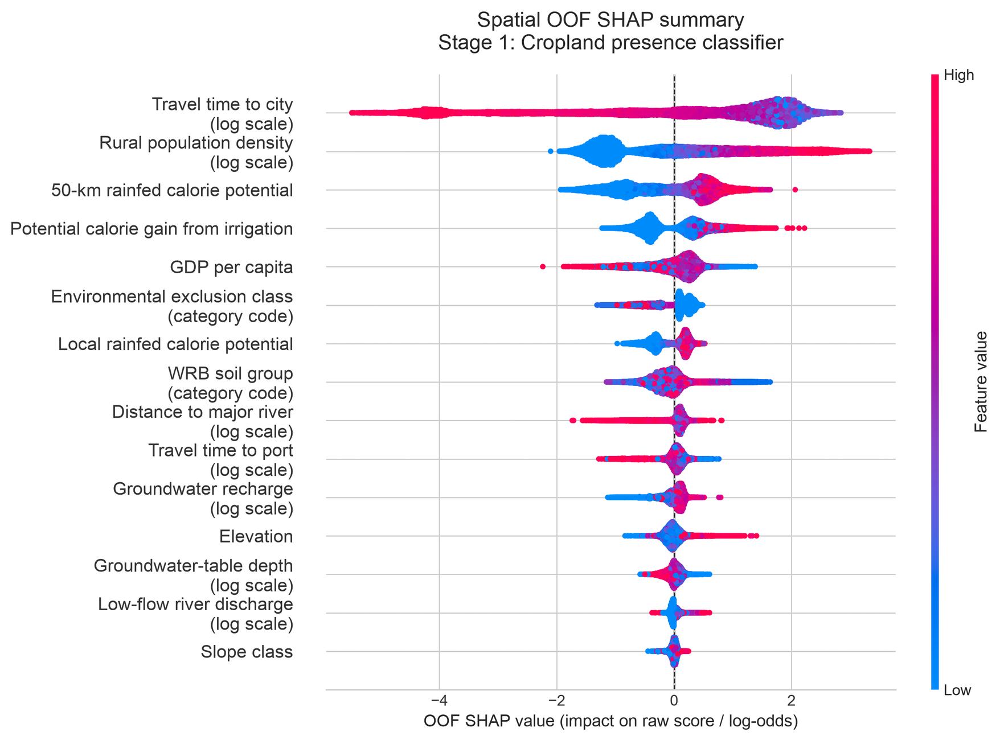

### Stage 2 OOF SHAP beeswarm

`saved_oof_shap_beeswarm/stage2_conditional_fraction_oof_shap_beeswarm.png`

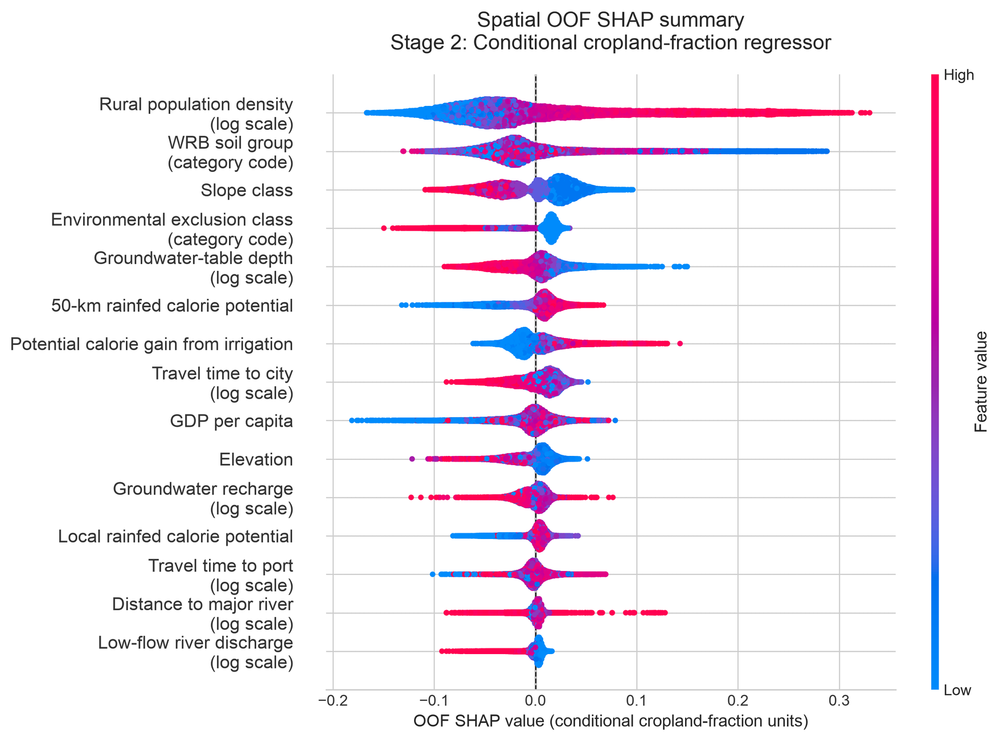

### 最終耕作地割合の統合SHAP beeswarm

`saved_oof_shap_beeswarm/integrated_final_fraction_oof_shap_beeswarm.png`

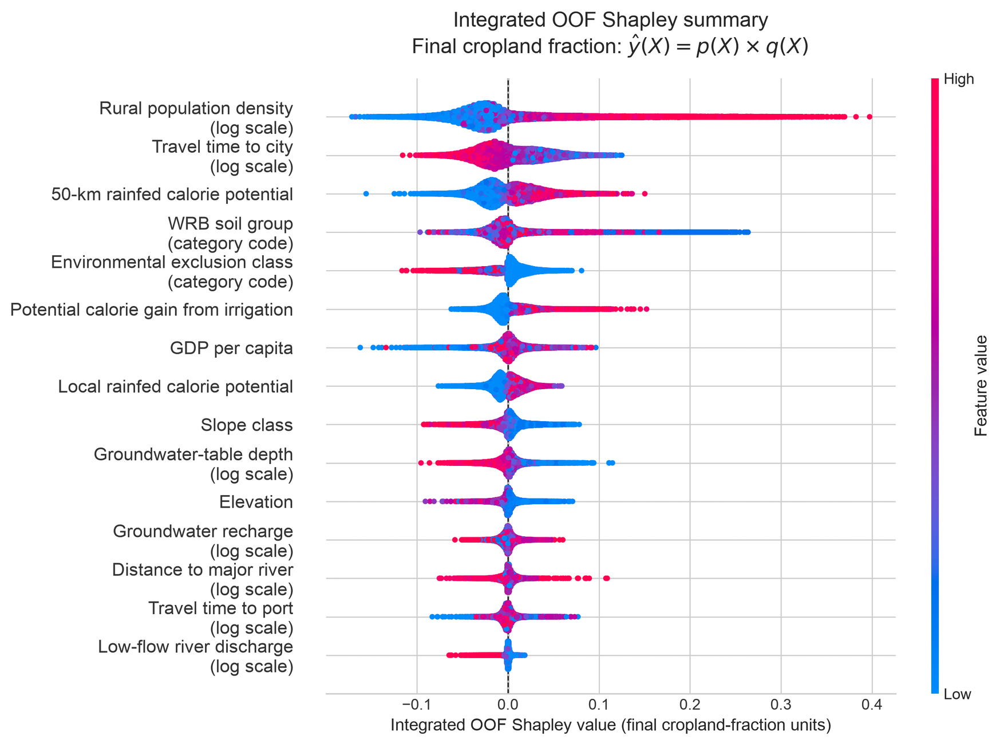

In [7]:
figure_specs = [('signed_factor_maps_stage1_presence.png', 'Stage 1：耕作地存在分類の要素群別signed SHAP'), ('signed_factor_maps_stage2_conditional.png', 'Stage 2：条件付き耕作地割合の要素群別signed SHAP'), ('saved_oof_shap_beeswarm/stage1_presence_oof_shap_beeswarm.png', 'Stage 1 OOF SHAP beeswarm'), ('saved_oof_shap_beeswarm/stage2_conditional_fraction_oof_shap_beeswarm.png', 'Stage 2 OOF SHAP beeswarm'), ('saved_oof_shap_beeswarm/integrated_final_fraction_oof_shap_beeswarm.png', '最終耕作地割合の統合SHAP beeswarm')]
for relative_path, caption in figure_specs:
    show_image(relative_path, caption)


## 変数値とSHAPの関係


### Stage 1 dependence plots — page 1

`feature_shap_dependence/presence_classifier_dependence_page_1.png`

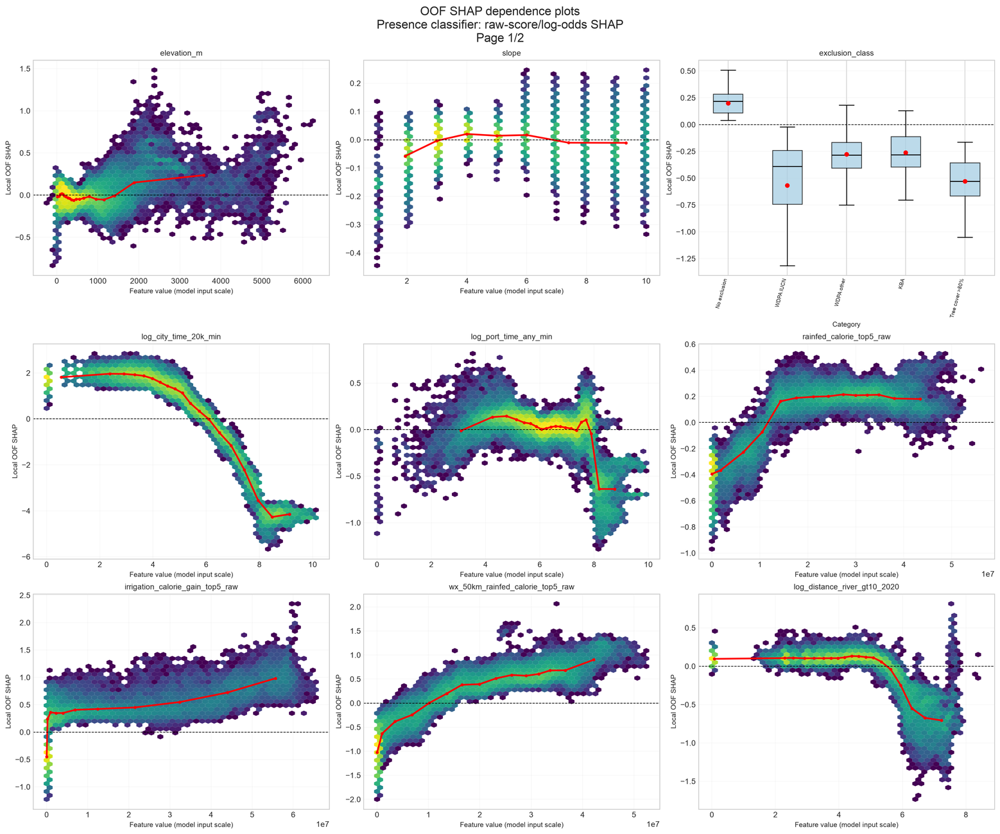

### Stage 1 dependence plots — page 2

`feature_shap_dependence/presence_classifier_dependence_page_2.png`

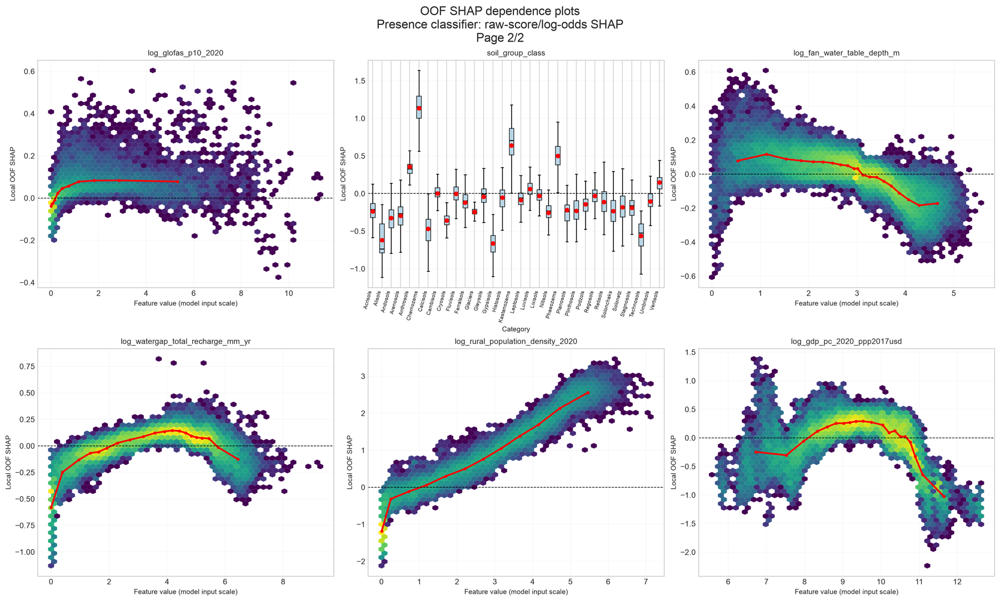

### Stage 2 dependence plots — page 1

`feature_shap_dependence/conditional_fraction_regressor_dependence_page_1.png`

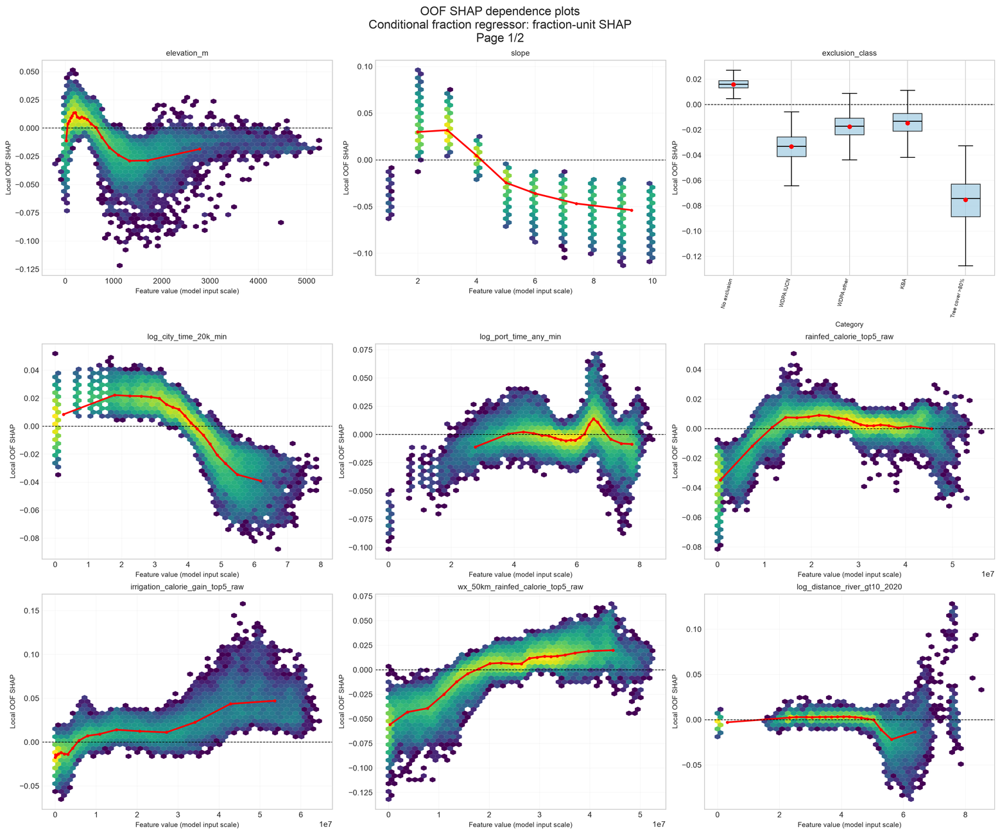

### Stage 2 dependence plots — page 2

`feature_shap_dependence/conditional_fraction_regressor_dependence_page_2.png`

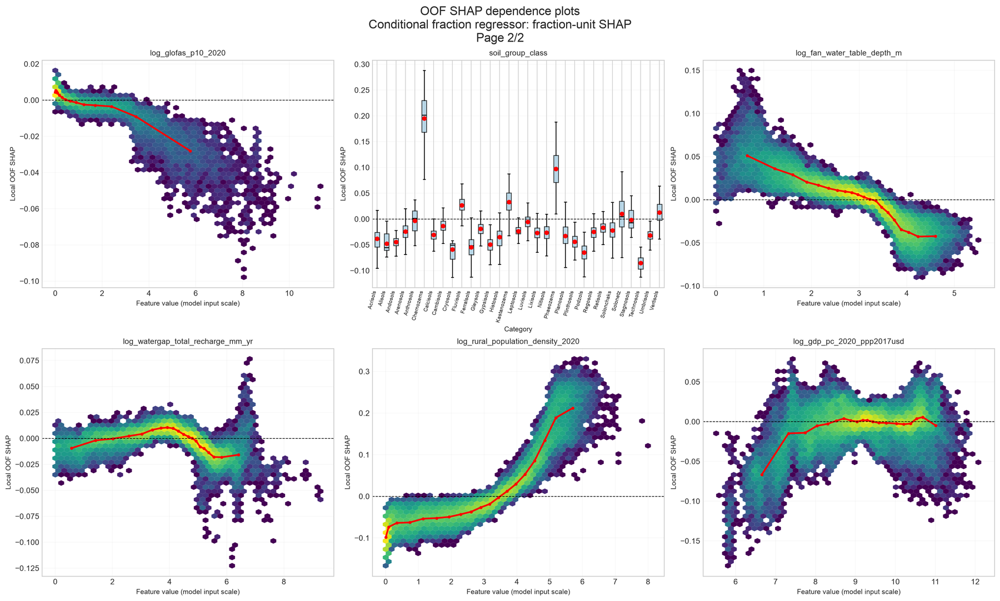

### 統合個別変数Shapley dependence

`integrated_final_feature_dependence_bg32_perm32/integrated_feature_dependence_old_style.png`

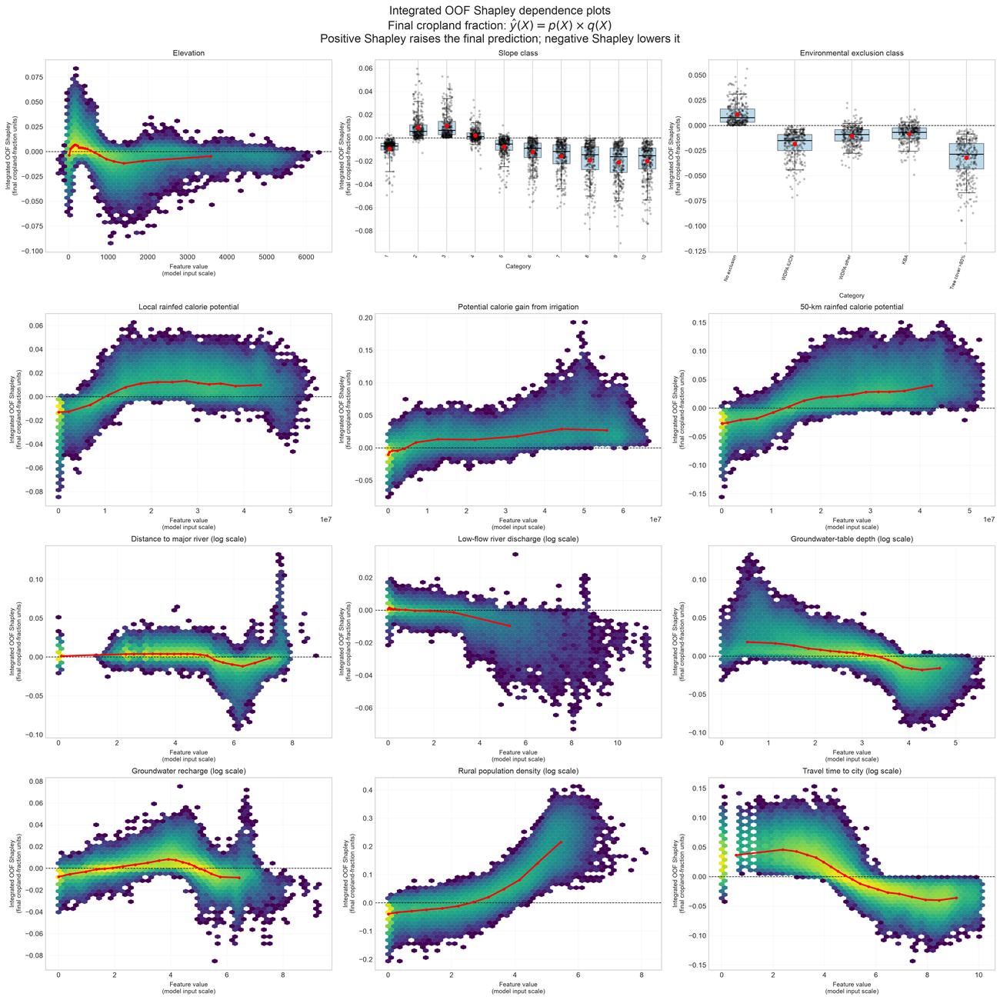

### 統合土壌群Shapley dependence

`integrated_final_feature_dependence_bg32_perm32/integrated_soil_group_dependence_old_style.png`

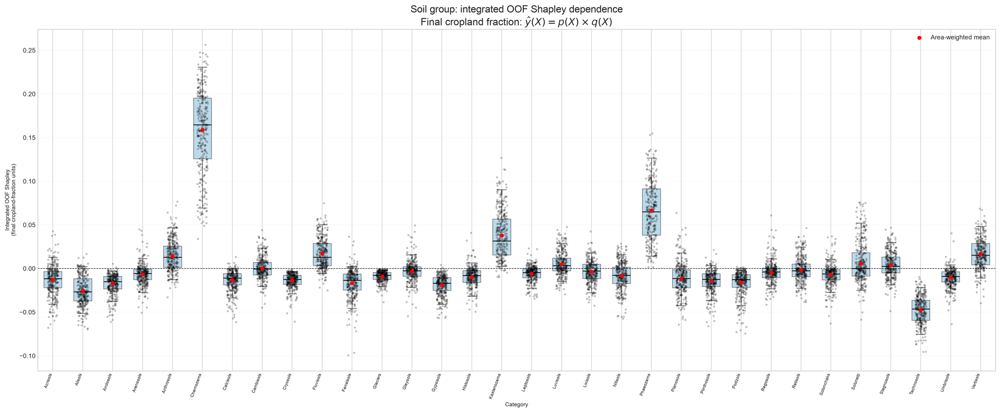

In [8]:
figure_specs = [('feature_shap_dependence/presence_classifier_dependence_page_1.png', 'Stage 1 dependence plots — page 1'), ('feature_shap_dependence/presence_classifier_dependence_page_2.png', 'Stage 1 dependence plots — page 2'), ('feature_shap_dependence/conditional_fraction_regressor_dependence_page_1.png', 'Stage 2 dependence plots — page 1'), ('feature_shap_dependence/conditional_fraction_regressor_dependence_page_2.png', 'Stage 2 dependence plots — page 2'), ('integrated_final_feature_dependence_bg32_perm32/integrated_feature_dependence_old_style.png', '統合個別変数Shapley dependence'), ('integrated_final_feature_dependence_bg32_perm32/integrated_soil_group_dependence_old_style.png', '統合土壌群Shapley dependence')]
for relative_path, caption in figure_specs:
    show_image(relative_path, caption)


## Permutation importance


### 個別変数Permutation importance

`permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_gdp_spatial_oof_permutation_importance.png`

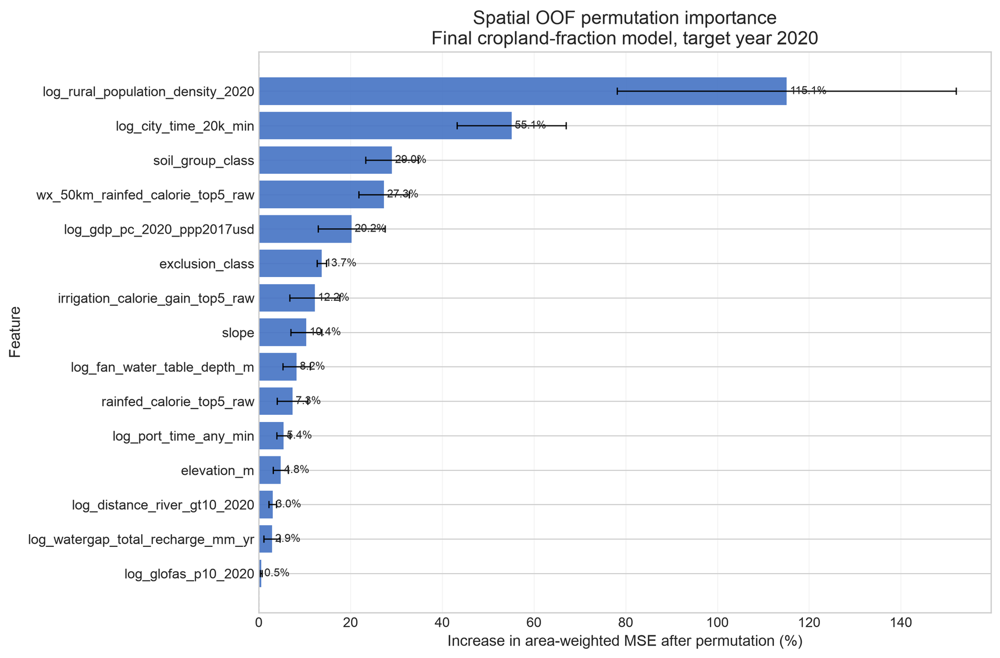

### 要素群Permutation importance

`group_permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_gdp_spatial_oof_group_permutation_importance.png`

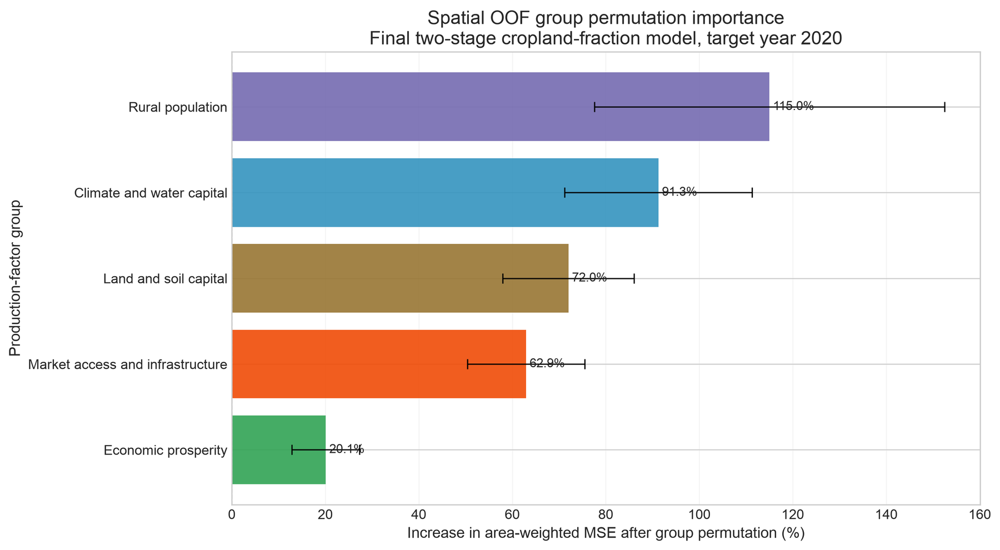

In [9]:
figure_specs = [('permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_gdp_spatial_oof_permutation_importance.png', '個別変数Permutation importance'), ('group_permutation_importance_final_oof/soil_group_wetland_excluded_groundwater_rural_population_gdp_spatial_oof_group_permutation_importance.png', '要素群Permutation importance')]
for relative_path, caption in figure_specs:
    show_image(relative_path, caption)


## 保存結果ファイルの完全な索引


In [10]:
inventory = []
for path in sorted(RESULT_DIR.rglob("*")):
    if not path.is_file():
        continue
    inventory.append({
        "relative_path": str(path.relative_to(RESULT_DIR)),
        "type": "".join(path.suffixes) or "file",
        "size_MB": path.stat().st_size / 1024**2,
    })
inventory_df = pd.DataFrame(inventory)
display(Markdown(
    f"**全{len(inventory_df):,}ファイル、合計"
    f"{inventory_df['size_MB'].sum():,.1f} MB**"
))
display(inventory_df)


**全91ファイル、合計593.5 MB**

,relative_path,type,size_MB
0,factor_group_oof_shap_corrected.png,.png,0.252304
1,factor_group_oof_shap_old_vs_corrected.png,.png,0.142965
2,feature_shap_dependence/conditional_fraction_r...,.png,1.237244
3,feature_shap_dependence/conditional_fraction_r...,.png,0.934425
4,feature_shap_dependence/presence_classifier_de...,.png,1.237036
...,...,...,...
86,soil_model_oof_local_group_shap.csv.gz,.csv.gz,4.525690
87,soil_model_oof_shap_factor_groups_corrected.csv,.csv,0.001671
88,soil_model_oof_shap_fold_summary.csv,.csv,0.024924
89,soil_model_oof_shap_summary.csv,.csv,0.008231


## 注意

この閲覧用ノートブックの出力は、保存済み結果を読み込んで再表示したものです。
新しいモデルの学習、Spatial OOF、SHAP、Permutation importanceの再計算は行っていません。
元の高解像度PNG・完全なCSV/Parquetは、各セルに記載した結果ディレクトリに残っています。
